# DL-SCA — Notebook consolidé : portabilité inter-appareils et adaptation de domaine

**Fil unique du projet, en trois temps** (le même que le chapitre scientifique) :

1. **Partie A — Validation** *(données ASCAD)* : on met en place la métrique d'attaque
   (*guessing entropy*), on la valide sans entraînement, puis on prouve que le deep
   learning casse la clé sur un benchmark connu (MLP, puis CNN).
2. **Partie B — Étude de portabilité** *(données AES_PT, 4 appareils)* : on profile sur
   un appareil D1, on attaque D1 (ça marche), puis D2/D3/D4 (ça s'effondre = le verrou).
   On teste deux corrections : renormalisation par appareil, puis **DANN**.
3. **Partie C — Synthèse** : on rassemble les chiffres dans un tableau unique et on
   exporte les figures prêtes pour le rapport.

> **Bon à savoir** : `AES_PT.h5` contient déjà les implémentations *Unprotected* ET
> *Masked* pour les 4 appareils. La Partie A (ASCAD) est donc **optionnelle** : si tu
> n'as pas `ASCAD.h5`, saute-la — la validation se fait aussi en B.1 (attaque D1→D1).
>
> Ce notebook remplace `ASCAD_01..04` + `Untitled1` (téléchargement raté, supprimable).

**Dépendance externe unique** : la fonction `load_aes_pt` est importée de ton
`sca_utils.py` (mets ce fichier dans le même dossier). Tout le reste est défini ici.

In [2]:
# --- Installation (à exécuter UNE fois si besoin) ----------------------------
# Colab : tout est déjà présent, tu peux ignorer cette cellule.
# Local / venv : si 'No module named tensorflow', décommente la ligne suivante.
# %pip install tensorflow scikit-learn h5py matplotlib pandas

## 0. Configuration et boîte à outils

Toutes les fonctions réutilisées sont définies **une seule fois** ici. Le reste du
notebook ne fait que les appeler — c'est ce qui le rend lisible.

In [10]:
# --- Plateforme et chemins ---------------------------------------------------
import os, numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/dl-sca'
except Exception:
    DATA_DIR = os.path.expanduser('~/Documents/ascad')

os.makedirs(DATA_DIR, exist_ok=True)
ASCAD_PATH  = os.path.join(DATA_DIR, 'ASCAD.h5')     # Partie A (AES masqué, 700 pts)
AES_PT_PATH = os.path.join(DATA_DIR, 'AES_PT.h5')    # Partie B (4 appareils)

FIG_DIR = os.path.join(DATA_DIR, 'figures')          # figures exportées pour le rapport
os.makedirs(FIG_DIR, exist_ok=True)

# Reproductibilité
SEED = 42
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
gpus = tf.config.list_physical_devices('GPU')
print('GPU      :', bool(gpus), '|', gpus if gpus else '(CPU — pense à activer le GPU sur Colab)')
print('ASCAD    :', ASCAD_PATH,  '|', 'présent' if os.path.exists(ASCAD_PATH)  else 'ABSENT')
print('AES_PT   :', AES_PT_PATH, '|', 'présent' if os.path.exists(AES_PT_PATH) else 'ABSENT')

GPU      : False | (CPU — pense à activer le GPU sur Colab)
ASCAD    : /home/user/Documents/ascad/ASCAD.h5 | présent
AES_PT   : /home/user/Documents/ascad/AES_PT.h5 | présent


In [11]:
# --- S-box AES ---------------------------------------------------------------
AES_SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16,
], dtype=np.uint8)

In [12]:
# --- Métrique : guessing entropy --------------------------------------------
def guessing_entropy(preds, plaintext_bytes, true_key_byte,
                     n_attack=1000, n_exp=50, seed=0):
    # Rang moyen de la vraie clé en fonction du nombre de traces cumulées.
    # preds : (N,256) probas ; plaintext_bytes : (N,) ; tend vers 0 si l'attaque réussit.
    rng = np.random.default_rng(seed)
    log_preds = np.log(preds + 1e-40)
    N = preds.shape[0]
    n_attack = min(n_attack, N)
    key_hyp = np.arange(256, dtype=np.uint8)
    ge = np.zeros(n_attack)
    for _ in range(n_exp):
        idx = rng.permutation(N)[:n_attack]
        scores = np.zeros(256)
        for step, i in enumerate(idx):
            scores += log_preds[i, AES_SBOX[plaintext_bytes[i] ^ key_hyp]]
            ge[step] += np.count_nonzero(scores > scores[true_key_byte])
    return ge / n_exp

def traces_to_break(ge, thresh=0.5):
    # Nombre de traces pour atteindre le rang 0 (None si jamais atteint).
    hit = np.where(ge < thresh)[0]
    return int(hit[0] + 1) if len(hit) else None

In [13]:
# --- Modèles -----------------------------------------------------------------
from tensorflow.keras import layers, models, optimizers

def make_mlp(n_samples, lr=1e-3, optimizer='adam', n_layers=6, width=200):
    m = models.Sequential([layers.Input(shape=(n_samples,))] +
        [layers.Dense(width, activation='relu') for _ in range(n_layers)] +
        [layers.Dense(256, activation='softmax')])
    opt = optimizers.RMSprop(lr) if optimizer == 'rmsprop' else optimizers.Adam(lr)
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def make_cnn(n_samples):
    # CNN compact type Zaid : une conv, un pooling, deux denses.
    inp = layers.Input(shape=(n_samples, 1))
    x = layers.Conv1D(4, 1, activation='selu', padding='same', kernel_initializer='he_uniform')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2, strides=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(10, activation='selu', kernel_initializer='he_uniform')(x)
    x = layers.Dense(10, activation='selu', kernel_initializer='he_uniform')(x)
    out = layers.Dense(256, activation='softmax')(x)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(5e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

In [14]:
# --- DANN : couche d'inversion de gradient + modèle adverse ------------------
class GradReverse(layers.Layer):
    def __init__(self, **kw):
        super().__init__(**kw)
        self.lamb = tf.Variable(0.0, trainable=False, dtype=tf.float32)
    def call(self, x):
        @tf.custom_gradient
        def f(z):
            return tf.identity(z), lambda dy: -self.lamb * dy
        return f(x)

def build_dann(n_samples):
    inp = layers.Input(shape=(n_samples,))
    x = layers.Dense(200, activation='relu')(inp)
    x = layers.Dense(200, activation='relu')(x)
    feat = layers.Dense(200, activation='relu')(x)
    c = layers.Dense(200, activation='relu')(feat)
    class_out = layers.Dense(256, activation='softmax', name='class')(c)
    d = GradReverse(name='grl')(feat)
    d = layers.Dense(100, activation='relu')(d)
    domain_out = layers.Dense(2, activation='softmax', name='domain')(d)
    model = models.Model(inp, {'class': class_out, 'domain': domain_out})
    model.compile(optimizer=optimizers.Adam(1e-3),
        loss={'class': 'sparse_categorical_crossentropy',
              'domain': 'sparse_categorical_crossentropy'},
        loss_weights={'class': 1.0, 'domain': 1.0},
        metrics={'class': 'accuracy', 'domain': 'accuracy'})
    return model

class LambdaSchedule(tf.keras.callbacks.Callback):
    # lambda = 0 pendant le warmup, puis montée sigmoïde jusqu'à max_lambda.
    def __init__(self, grl, total, warmup=20, gamma=10.0, max_lambda=0.5):
        self.grl = grl; self.total = total; self.warmup = warmup
        self.gamma = gamma; self.maxl = max_lambda
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup:
            lam = 0.0
        else:
            p = (epoch - self.warmup) / max(1, self.total - self.warmup - 1)
            lam = (2.0 / (1.0 + np.exp(-self.gamma * p)) - 1.0) * self.maxl
        self.grl.lamb.assign(np.float32(lam))

In [15]:
# --- Chargeurs de données ----------------------------------------------------
import h5py
from sklearn.preprocessing import StandardScaler

def load_ascad(path, target_byte=2):
    # ASCAD v1 clé fixe : labels = Z = Sbox(pt[byte] ^ key[byte]), déjà fournis.
    with h5py.File(path, 'r') as f:
        X_prof = np.array(f['Profiling_traces/traces'], dtype=np.float32)
        y_prof = np.array(f['Profiling_traces/labels'], dtype=np.int64)
        X_atk  = np.array(f['Attack_traces/traces'],   dtype=np.float32)
        y_atk  = np.array(f['Attack_traces/labels'],   dtype=np.int64)
        m_atk  = f['Attack_traces/metadata'][:]
    pt_atk   = m_atk['plaintext'][:, target_byte].astype(np.uint8)
    true_key = int(np.bincount(m_atk['key'][:, target_byte].astype(np.uint8)).argmax())
    return dict(X_prof=X_prof, y_prof=y_prof, X_atk=X_atk, y_atk=y_atk,
                pt_atk=pt_atk, true_key=true_key)

# AES_PT : chargeur écrit pour la structure exacte de TON fichier
# Chemins : {device}/{impl}/{keytype}/Traces  et  .../Data/{Plaintext,Key}
#   device  in D1..D4 | impl in 'Unprotected','Masked' | keytype in 'RndmKey','FixedKey'
# Étiquette de fuite : Z = Sbox(plaintext[byte] XOR key[byte])  (256 classes).
def load_aes_pt(path, device='D1', impl='Unprotected', keytype='RndmKey', byte=0, n=None):
    base = f'{device}/{impl}/{keytype}'
    with h5py.File(path, 'r') as f:
        tr = f[f'{base}/Traces']
        N = tr.shape[0] if n is None else min(int(n), tr.shape[0])
        traces = np.asarray(tr[:N], dtype=np.float32)
        pt  = np.asarray(f[f'{base}/Data/Plaintext'][:N, byte], dtype=np.uint8)
        key = np.asarray(f[f'{base}/Data/Key'][:N, byte], dtype=np.uint8)
    labels = AES_SBOX[pt ^ key].astype(np.int64)
    return {'traces': traces, 'labels': labels, 'pt': pt, 'key': key}

PARTIE_B_OK = os.path.exists(AES_PT_PATH)
print('AES_PT présent -> Partie B prête :', PARTIE_B_OK)

AES_PT présent -> Partie B prête : True


---
## Partie A — Validation de la chaîne sur ASCAD

Objectif : prouver que la métrique est correcte et que le DL-SCA casse une clé sur un
benchmark de référence. C'est ce qui légitime tout le reste.

### A.1 Télécharger ASCAD (optionnel, une seule fois)
Campagne **clé fixe** (700 points, octet 2). Le paquet officiel pèse ~4,2 Go au
téléchargement ; on n'en extrait que `ASCAD.h5` (~170 Mo). Le dépôt ANSSI est archivé
depuis janvier 2026 mais les données restent hébergées sur data.gouv.
Si tu n'as pas besoin de la validation ASCAD, **saute cette partie** (la validation se
fait aussi en B.1, attaque D1→D1 sur des données que tu as déjà).

In [9]:
import os
if os.path.exists(ASCAD_PATH):
    print('ASCAD déjà présent :', ASCAD_PATH)
else:
    import urllib.request, zipfile, shutil
    # Lien officiel courant (campagne clé fixe, 700 points). ~4.2 Go à télécharger.
    URL = 'https://www.data.gouv.fr/api/1/datasets/r/e7ab6f9e-79bf-431f-a5ed-faf0ebe9b08e'
    ZIP = os.path.join(DATA_DIR, 'ASCAD_data.zip')
    print('Téléchargement ASCAD (~4.2 Go, une seule fois)…')
    def _hook(b, bs, total):
        done = b * bs
        pct = 100 * done / total if total > 0 else 0
        print(f'\r  {done/1e9:5.2f} / {total/1e9:5.2f} Go ({pct:4.1f} %)', end='')
    urllib.request.urlretrieve(URL, ZIP, _hook); print()
    # On extrait UNIQUEMENT ASCAD.h5 (évite ~7 Go : raw traces + modèles inutiles ici)
    with zipfile.ZipFile(ZIP) as z:
        names = z.namelist()
        cands = ([m for m in names if m.endswith('ASCAD_databases/ASCAD.h5')]
                 or [m for m in names if os.path.basename(m) == 'ASCAD.h5'])
        with z.open(cands[0]) as fsrc, open(ASCAD_PATH, 'wb') as fdst:
            shutil.copyfileobj(fsrc, fdst)
    os.remove(ZIP)
    print('OK ->', ASCAD_PATH, '|', round(os.path.getsize(ASCAD_PATH)/1e6, 1), 'Mo')

Téléchargement ASCAD (~4.2 Go, une seule fois)…
   3.94 /  4.44 Go (88.9 %)

ContentTooShortError: <urlopen error retrieval incomplete: got only 3940797016 out of 4435199469 bytes>

### A.2 Charger, standardiser, valider la métrique
On standardise (fit sur le profilage). Puis deux contrôles **sans entraînement** :
oracle parfait → doit tomber à 0 ; hasard → doit rester ~128.

Profilage (50000, 700) | Attaque (10000, 700) | clé à retrouver : 224


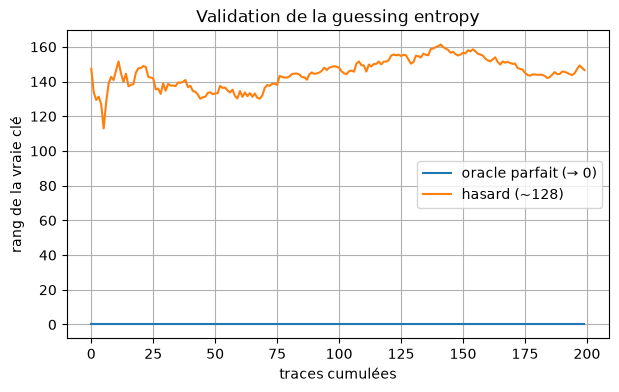

Oracle final = 0.0 | Hasard moyen = 144.8


In [16]:
asc = load_ascad(ASCAD_PATH, target_byte=2)
scaler = StandardScaler().fit(asc['X_prof'])
Xp_std = scaler.transform(asc['X_prof']).astype(np.float32)
Xa_std = scaler.transform(asc['X_atk']).astype(np.float32)
N_SAMPLES = Xp_std.shape[1]
print('Profilage', Xp_std.shape, '| Attaque', Xa_std.shape, '| clé à retrouver :', asc['true_key'])

import matplotlib.pyplot as plt
N = Xa_std.shape[0]
oracle = np.full((N, 256), 1e-6, np.float32)
oracle[np.arange(N), AES_SBOX[asc['pt_atk'] ^ np.uint8(asc['true_key'])]] = 1.0
ge_oracle = guessing_entropy(oracle, asc['pt_atk'], asc['true_key'], n_attack=200, n_exp=20)
rng = np.random.default_rng(0)
rand = rng.random((N, 256)).astype(np.float32); rand /= rand.sum(1, keepdims=True)
ge_rand = guessing_entropy(rand, asc['pt_atk'], asc['true_key'], n_attack=200, n_exp=20)

plt.figure(figsize=(7,4))
plt.plot(ge_oracle, label='oracle parfait (→ 0)'); plt.plot(ge_rand, label='hasard (~128)')
plt.xlabel('traces cumulées'); plt.ylabel('rang de la vraie clé')
plt.title('Validation de la guessing entropy'); plt.legend(); plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, 'A_validation_ge.pdf'), bbox_inches='tight'); plt.show()
print('Oracle final =', round(ge_oracle[-1],1), '| Hasard moyen =', round(ge_rand.mean(),1))

### A.3 Baseline MLP
Baseline historique ASCAD : 6 couches denses de 200, RMSprop 1e-5.

In [17]:
mlp = make_mlp(N_SAMPLES, lr=1e-5, optimizer='rmsprop')
mlp.fit(Xp_std, asc['y_prof'], epochs=100, batch_size=100,
        validation_data=(Xa_std, asc['y_atk']), verbose=2)

preds_mlp = mlp.predict(Xa_std, batch_size=256, verbose=0)
ge_mlp = guessing_entropy(preds_mlp, asc['pt_atk'], asc['true_key'], n_attack=1000, n_exp=100)
print('MLP : casse à', traces_to_break(ge_mlp), 'traces')

Epoch 1/100
500/500 - 6s - 13ms/step - accuracy: 0.0040 - loss: 5.5523 - val_accuracy: 0.0035 - val_loss: 5.5485
Epoch 2/100
500/500 - 5s - 10ms/step - accuracy: 0.0038 - loss: 5.5469 - val_accuracy: 0.0034 - val_loss: 5.5474
Epoch 3/100
500/500 - 5s - 11ms/step - accuracy: 0.0041 - loss: 5.5449 - val_accuracy: 0.0036 - val_loss: 5.5469
Epoch 4/100
500/500 - 5s - 11ms/step - accuracy: 0.0042 - loss: 5.5436 - val_accuracy: 0.0037 - val_loss: 5.5467
Epoch 5/100
500/500 - 5s - 10ms/step - accuracy: 0.0044 - loss: 5.5425 - val_accuracy: 0.0037 - val_loss: 5.5467
Epoch 6/100
500/500 - 5s - 10ms/step - accuracy: 0.0046 - loss: 5.5415 - val_accuracy: 0.0034 - val_loss: 5.5466
Epoch 7/100
500/500 - 5s - 10ms/step - accuracy: 0.0047 - loss: 5.5406 - val_accuracy: 0.0030 - val_loss: 5.5467
Epoch 8/100
500/500 - 5s - 11ms/step - accuracy: 0.0047 - loss: 5.5397 - val_accuracy: 0.0029 - val_loss: 5.5468
Epoch 9/100
500/500 - 5s - 10ms/step - accuracy: 0.0046 - loss: 5.5389 - val_accuracy: 0.0028 - 

### A.4 Baseline CNN (type Zaid)

In [18]:
cnn = make_cnn(N_SAMPLES)
cnn.fit(Xp_std[..., None], asc['y_prof'], epochs=50, batch_size=50,
        validation_data=(Xa_std[..., None], asc['y_atk']), verbose=2)

preds_cnn = cnn.predict(Xa_std[..., None], batch_size=256, verbose=0)
ge_cnn = guessing_entropy(preds_cnn, asc['pt_atk'], asc['true_key'], n_attack=1000, n_exp=100)
print('CNN : casse à', traces_to_break(ge_cnn), 'traces')

Epoch 1/50
1000/1000 - 5s - 5ms/step - accuracy: 0.0039 - loss: 5.5712 - val_accuracy: 0.0031 - val_loss: 5.5539
Epoch 2/50
1000/1000 - 5s - 5ms/step - accuracy: 0.0046 - loss: 5.5479 - val_accuracy: 0.0031 - val_loss: 5.5611
Epoch 3/50
1000/1000 - 7s - 7ms/step - accuracy: 0.0051 - loss: 5.5453 - val_accuracy: 0.0039 - val_loss: 5.5670
Epoch 4/50
1000/1000 - 9s - 9ms/step - accuracy: 0.0054 - loss: 5.5437 - val_accuracy: 0.0033 - val_loss: 5.5699
Epoch 5/50
1000/1000 - 9s - 9ms/step - accuracy: 0.0060 - loss: 5.5428 - val_accuracy: 0.0033 - val_loss: 5.5754
Epoch 6/50
1000/1000 - 6s - 6ms/step - accuracy: 0.0053 - loss: 5.5426 - val_accuracy: 0.0037 - val_loss: 5.5856
Epoch 7/50
1000/1000 - 6s - 6ms/step - accuracy: 0.0053 - loss: 5.5427 - val_accuracy: 0.0037 - val_loss: 5.5888
Epoch 8/50
1000/1000 - 9s - 9ms/step - accuracy: 0.0048 - loss: 5.5427 - val_accuracy: 0.0039 - val_loss: 5.5799
Epoch 9/50
1000/1000 - 4s - 4ms/step - accuracy: 0.0047 - loss: 5.5429 - val_accuracy: 0.0039 - 

### A.5 Comparaison MLP vs CNN

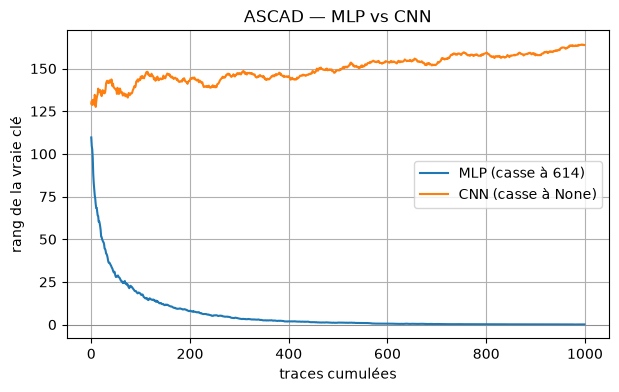

In [19]:
plt.figure(figsize=(7,4))
plt.plot(ge_mlp, label=f"MLP (casse à {traces_to_break(ge_mlp)})")
plt.plot(ge_cnn, label=f"CNN (casse à {traces_to_break(ge_cnn)})")
plt.axhline(0, color='gray', lw=0.5); plt.legend(); plt.grid(True)
plt.xlabel('traces cumulées'); plt.ylabel('rang de la vraie clé'); plt.title('ASCAD — MLP vs CNN')
plt.savefig(os.path.join(FIG_DIR, 'A_mlp_vs_cnn.pdf'), bbox_inches='tight'); plt.show()

---
## Partie B — Portabilité inter-appareils (AES_PT)

Le cœur de ta contribution. On profile sur **D1** et on attaque les autres appareils.
On commence sur l'AES **non protégé** (fuite directe) pour valider la chaîne complète.

In [20]:
TARGET_BYTE = 0           # essaie 1, 2... si la clé ne sort pas
IMPL        = 'Unprotected'

def attaquer(model, traces, scaler, pt, true_key, n_attack=1000, n_exp=50):
    X = scaler.transform(traces).astype(np.float32)
    preds = model.predict(X, batch_size=256, verbose=0)
    return guessing_entropy(preds, pt, true_key, n_attack=n_attack, n_exp=n_exp)

### B.1 Profilage sur D1 et attaque D1 (validation même-appareil)
Profilage avec **clés aléatoires** ; attaque sur la **clé fixe** de D1. Doit casser.

In [21]:
prof = load_aes_pt(AES_PT_PATH, device='D1', impl=IMPL, keytype='RndmKey',
                   byte=TARGET_BYTE, n=50000)
scaler_D1 = StandardScaler().fit(prof['traces'])
Xp = scaler_D1.transform(prof['traces']).astype(np.float32)

mlp_pt = make_mlp(Xp.shape[1], lr=1e-3)
mlp_pt.fit(Xp, prof['labels'], epochs=30, batch_size=128, verbose=2)

atkD1 = load_aes_pt(AES_PT_PATH, device='D1', impl=IMPL, keytype='FixedKey',
                    byte=TARGET_BYTE, n=20000)
tkD1 = int(np.bincount(atkD1['key']).argmax())
ge_same = attaquer(mlp_pt, atkD1['traces'], scaler_D1, atkD1['pt'], tkD1)
print('D1 -> D1 : casse à', traces_to_break(ge_same), 'traces')

Epoch 1/30
391/391 - 6s - 15ms/step - accuracy: 0.0042 - loss: 5.5332
Epoch 2/30
391/391 - 5s - 12ms/step - accuracy: 0.0061 - loss: 5.2637
Epoch 3/30
391/391 - 4s - 10ms/step - accuracy: 0.0083 - loss: 5.0061
Epoch 4/30
391/391 - 4s - 10ms/step - accuracy: 0.0106 - loss: 4.8383
Epoch 5/30
391/391 - 4s - 10ms/step - accuracy: 0.0113 - loss: 4.7504
Epoch 6/30
391/391 - 4s - 10ms/step - accuracy: 0.0125 - loss: 4.6925
Epoch 7/30
391/391 - 4s - 10ms/step - accuracy: 0.0144 - loss: 4.6541
Epoch 8/30
391/391 - 5s - 12ms/step - accuracy: 0.0172 - loss: 4.6052
Epoch 9/30
391/391 - 5s - 12ms/step - accuracy: 0.0204 - loss: 4.5692
Epoch 10/30
391/391 - 5s - 12ms/step - accuracy: 0.0251 - loss: 4.5111
Epoch 11/30
391/391 - 5s - 12ms/step - accuracy: 0.0306 - loss: 4.4361
Epoch 12/30
391/391 - 5s - 12ms/step - accuracy: 0.0374 - loss: 4.3484
Epoch 13/30
391/391 - 4s - 11ms/step - accuracy: 0.0436 - loss: 4.2637
Epoch 14/30
391/391 - 4s - 10ms/step - accuracy: 0.0525 - loss: 4.1774
Epoch 15/30
391

### B.2 Transfert naïf D1 → D2/D3/D4 — l'écart de portabilité
Même modèle, même échelle (celle de D1). On s'attend à une dégradation : c'est le verrou.

D1 -> D2 (naïf) : casse à None traces
D1 -> D3 (naïf) : casse à None traces
D1 -> D4 (naïf) : casse à None traces


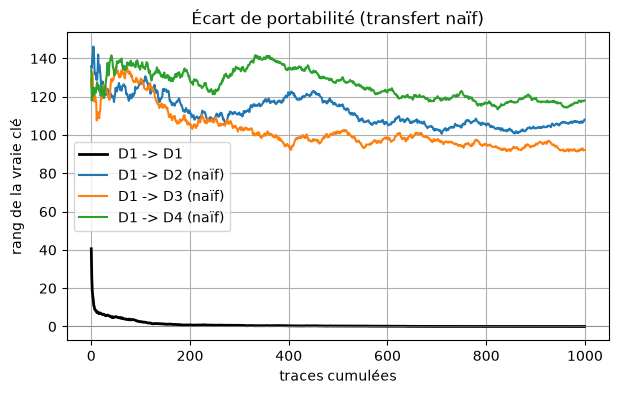

In [22]:
ge_naive = {}
for dev in ['D2', 'D3', 'D4']:
    atk = load_aes_pt(AES_PT_PATH, device=dev, impl=IMPL, keytype='FixedKey',
                      byte=TARGET_BYTE, n=20000)
    tk = int(np.bincount(atk['key']).argmax())
    ge_naive[dev] = attaquer(mlp_pt, atk['traces'], scaler_D1, atk['pt'], tk)
    print(f'D1 -> {dev} (naïf) : casse à', traces_to_break(ge_naive[dev]), 'traces')

plt.figure(figsize=(7,4)); plt.plot(ge_same, 'k', lw=2, label='D1 -> D1')
for dev, g in ge_naive.items(): plt.plot(g, label=f'D1 -> {dev} (naïf)')
plt.axhline(0, color='gray', lw=0.5); plt.legend(); plt.grid(True)
plt.xlabel('traces cumulées'); plt.ylabel('rang de la vraie clé')
plt.title("Écart de portabilité (transfert naïf)")
plt.savefig(os.path.join(FIG_DIR, 'B_portabilite_naif.pdf'), bbox_inches='tight'); plt.show()

### B.3 Correction 1 — renormalisation par appareil
On renormalise les traces cibles avec **leurs propres** statistiques (l'attaquant a les
traces, pas besoin des clés). Souvent insuffisant — d'où le DANN ensuite.

In [23]:
ge_adapt = {}
for dev in ['D2', 'D3', 'D4']:
    atk = load_aes_pt(AES_PT_PATH, device=dev, impl=IMPL, keytype='FixedKey',
                      byte=TARGET_BYTE, n=20000)
    tk = int(np.bincount(atk['key']).argmax())
    scaler_dev = StandardScaler().fit(atk['traces'])
    ge_adapt[dev] = attaquer(mlp_pt, atk['traces'], scaler_dev, atk['pt'], tk)
    print(f'D1 -> {dev} (renorm) : casse à', traces_to_break(ge_adapt[dev]), 'traces')

D1 -> D2 (renorm) : casse à None traces
D1 -> D3 (renorm) : casse à None traces
D1 -> D4 (renorm) : casse à None traces


### B.4 Correction 2 — adaptation de domaine (DANN)
Source = D1 (étiqueté), cible = D2 (non étiqueté). La couche d'inversion de gradient
force le tronc à apprendre des features **indépendantes de l'appareil**.

> **Préparation des données corrigée** (manquait dans l'ancien NB4) : on empile
> source+cible ; labels de classe = ceux de la source + remplissage ignoré côté cible
> (poids 0) ; labels de domaine = 0 (source) / 1 (cible).

In [24]:
SRC_DEV, TGT_DEV = 'D1', 'D2'
N_TRAIN = 40000
EPOCHS, WARMUP = 60, 20

src = load_aes_pt(AES_PT_PATH, device=SRC_DEV, impl=IMPL, keytype='RndmKey', byte=TARGET_BYTE, n=N_TRAIN)
tgt = load_aes_pt(AES_PT_PATH, device=TGT_DEV, impl=IMPL, keytype='RndmKey', byte=TARGET_BYTE, n=N_TRAIN)

scaler_src = StandardScaler().fit(src['traces'])
scaler_tgt = StandardScaler().fit(tgt['traces'])
Xs = scaler_src.transform(src['traces']).astype(np.float32)
Xt = scaler_tgt.transform(tgt['traces']).astype(np.float32)
ns, nt = len(Xs), len(Xt)

# --- préparation DANN (le correctif) ---
X        = np.concatenate([Xs, Xt]).astype(np.float32)
y_class  = np.concatenate([src['labels'], np.zeros(nt)]).astype(np.int64)      # cible = bidon
y_domain = np.concatenate([np.zeros(ns), np.ones(nt)]).astype(np.int64)        # 0=source 1=cible
w_class  = np.concatenate([np.ones(ns), np.zeros(nt)]).astype(np.float32)      # ignore la cible
w_domain = np.ones(ns + nt, np.float32)

dann = build_dann(Xs.shape[1])
sched = LambdaSchedule(dann.get_layer('grl'), EPOCHS, warmup=WARMUP, max_lambda=0.5)
dann.fit(X, {'class': y_class, 'domain': y_domain},
         sample_weight={'class': w_class, 'domain': w_domain},
         epochs=EPOCHS, batch_size=128, shuffle=True, verbose=2, callbacks=[sched])

Epoch 1/60
625/625 - 8s - 13ms/step - class_accuracy: 0.0026 - class_loss: 2.7710 - domain_accuracy: 0.7265 - domain_loss: 0.5357 - loss: 3.3068
Epoch 2/60
625/625 - 7s - 11ms/step - class_accuracy: 0.0038 - class_loss: 2.6687 - domain_accuracy: 0.7666 - domain_loss: 0.4855 - loss: 3.1542
Epoch 3/60
625/625 - 7s - 11ms/step - class_accuracy: 0.0055 - class_loss: 2.5328 - domain_accuracy: 0.8033 - domain_loss: 0.4253 - loss: 2.9581
Epoch 4/60
625/625 - 6s - 10ms/step - class_accuracy: 0.0090 - class_loss: 2.4168 - domain_accuracy: 0.8512 - domain_loss: 0.3400 - loss: 2.7567
Epoch 5/60
625/625 - 7s - 10ms/step - class_accuracy: 0.0129 - class_loss: 2.3162 - domain_accuracy: 0.8760 - domain_loss: 0.2902 - loss: 2.6065
Epoch 6/60
625/625 - 7s - 11ms/step - class_accuracy: 0.0185 - class_loss: 2.2344 - domain_accuracy: 0.8859 - domain_loss: 0.2728 - loss: 2.5072
Epoch 7/60
625/625 - 7s - 10ms/step - class_accuracy: 0.0250 - class_loss: 2.1617 - domain_accuracy: 0.8896 - domain_loss: 0.2665 

D1->D2 source seul : None traces
D1->D2 DANN        : None traces


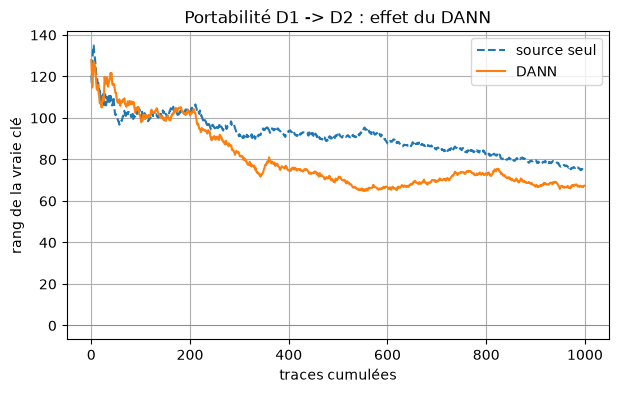

In [25]:
# Comparaison source-seul vs DANN sur la clé fixe de la cible
src_only = make_mlp(Xs.shape[1], lr=1e-3)
src_only.fit(Xs, src['labels'], epochs=30, batch_size=128, verbose=0)

atk = load_aes_pt(AES_PT_PATH, device=TGT_DEV, impl=IMPL, keytype='FixedKey', byte=TARGET_BYTE, n=20000)
tk_tgt = int(np.bincount(atk['key']).argmax())
Xa = scaler_tgt.transform(atk['traces']).astype(np.float32)

ge_srconly = guessing_entropy(src_only.predict(Xa, batch_size=256, verbose=0),
                              atk['pt'], tk_tgt, n_attack=1000, n_exp=50)
ge_dann    = guessing_entropy(dann.predict(Xa, batch_size=256, verbose=0)['class'],
                              atk['pt'], tk_tgt, n_attack=1000, n_exp=50)
print(f'{SRC_DEV}->{TGT_DEV} source seul :', traces_to_break(ge_srconly), 'traces')
print(f'{SRC_DEV}->{TGT_DEV} DANN        :', traces_to_break(ge_dann), 'traces')

plt.figure(figsize=(7,4))
plt.plot(ge_srconly, '--', label='source seul'); plt.plot(ge_dann, '-', label='DANN')
plt.axhline(0, color='gray', lw=0.5); plt.legend(); plt.grid(True)
plt.xlabel('traces cumulées'); plt.ylabel('rang de la vraie clé')
plt.title(f'Portabilité {SRC_DEV} -> {TGT_DEV} : effet du DANN')
plt.savefig(os.path.join(FIG_DIR, 'B_dann_D1_D2.pdf'), bbox_inches='tight'); plt.show()

---
## Partie C — Synthèse des résultats

On rassemble tout dans **un seul tableau** « traces pour casser » et on l'exporte en CSV.
C'est ce tableau qui alimente directement les sections Résultats et Discussion du rapport.

> Pour un tableau complet, relance la Partie B.4 avec `TGT_DEV = 'D3'` puis `'D4'` et
> stocke les `traces_to_break` correspondants dans `dann_results` ci-dessous.

In [29]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 27.2 MB/s  0:00:00a 0:00:01eta 0:00:02
Note: you may need to restart the kernel to use updated packages.


In [30]:

dann_results = {'D2': traces_to_break(ge_dann)}   # complète avec D3, D4 après relance

rows = []
for dev in ['D2', 'D3', 'D4']:
    rows.append({
        'Cible': dev,
        'Transfert naïf':   traces_to_break(ge_naive[dev]) if dev in ge_naive else None,
        'Renorm. appareil': traces_to_break(ge_adapt[dev]) if dev in ge_adapt else None,
        'DANN':             dann_results.get(dev),
    })
df = pd.DataFrame(rows).set_index('Cible')
df.to_csv(os.path.join(FIG_DIR, 'C_resultats_traces.csv'))
print('Traces pour atteindre le rang 0 (None = clé non récupérée) :')
df

Traces pour atteindre le rang 0 (None = clé non récupérée) :


,Transfert naïf,Renorm. appareil,DANN
Cible,,,
D2,None,None,None
D3,None,None,None
D4,None,None,None


### Bilan
- **Partie A** valide la chaîne : la clé sort sur ASCAD (MLP et CNN).
- **Partie B** quantifie le verrou de portabilité et montre que la renormalisation ne
  suffit pas, là où le DANN restaure (au moins partiellement) la fuite exploitable.
- **Partie C** condense tout dans un tableau réutilisable.

**Pour solidifier** (et muscler la contribution) : étendre le DANN à D3/D4, moyenner sur
plusieurs graines (barres d'erreur), puis tenter l'AES **masqué**. Les figures sont déjà
exportées dans `FIG_DIR` pour ton rapport LaTeX.